# Identifying Stellar Cluster Members with a Random Forest Classifier

This project uses a supervised machine learning approach to identify candidate members of a stellar cluster based on astrometric and photometric data. A Random Forest classifier is trained on known members and applied to a broader field sample to identify new candidates.

#### Scientific Motivation:
Stellar clusters are useful laboratories for studying stellar evolution because their members formed at roughly the same time and distance. A major challenge  is distinguishing true cluster members from foreground and background star field stars. Since confirmed memberships are often incomplete, a machine learning classifier can help identify stars with properties consistent with the known cluster population.

#### Project Overview:
In this notebook, I build a random forest classifier to identify likely members of the Praesepe Cluster using stellar propeties such as astrometry (RA, Dec, parallax, proper motion) and photometry (G, BP, RP magnitudes). The target variable (`cluster_membership`) indicates whether a star is a confirmed cluster member. The goal is to show a full machine learning workflow: 
- load the data
- preprocess the inputs
- train the classifier
- evaulate the model performance
- use the tranined model to identify new candidate members of Praesepe

In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# Plot style
mpl.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 1.5,
    "axes.labelweight": "semibold",
    "axes.titleweight": "semibold",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "font.size": 12,
})

colors = cm.viridis(np.linspace(0,1,6))

RSEED = 42
DATA_DIR = Path("data")

In [153]:
# Select relevant columns
RAW_COLS = [
    "source_id",
    "ra",
    "dec",
    "parallax",
    "pmra",
    "pmdec",
    "phot_g_mean_mag",
    "phot_bp_mean_mag",
    "phot_rp_mean_mag",
    "bp_rp",
    "bp_g",
    "g_rp",
]

# Cleaner notebook names
RENAME_MAP = {
    "source_id": "source_id",
    "ra": "ra",
    "dec": "dec",
    "parallax": "parallax",
    "pmra": "pmra",
    "pmdec": "pmdec",
    "phot_g_mean_mag": "gmag",
    "phot_bp_mean_mag": "bp_mag",
    "phot_rp_mean_mag": "rp_mag",
    "bp_rp": "bp_rp",
    "bp_g": "bp_g",
    "g_rp": "g_rp",
}

FEATURE_COLS = [
    "ra",
    "dec",
    "parallax",
    "pmra",
    "pmdec",
    "gmag",
    "bp_mag",
    "rp_mag",
    "bp_rp",
    "bp_g",
    "g_rp",
]

In [160]:
def load_catalog(path: str | Path) -> pd.DataFrame:
    """Load an Excel catalog and standardize the column names."""
    df = pd.read_excel(path)
    df = df[RAW_COLS].rename(columns=RENAME_MAP).copy()
    return df

def clean_catalog(df: pd.DataFrame, zero_invalid_cols=None) -> pd.DataFrame:
    """Drop rows with NaNs and optionally remove rows with zeros in selected columns."""
    clean_df = df.dropna(subset=FEATURE_COLS).copy()

    if zero_invalid_cols is None:
        zero_invalid_cols = FEATURE_COLS

    for col in zero_invalid_cols:
        clean_df = clean_df[clean_df[col] != 0]

    clean_df = clean_df.reset_index(drop=True)
    return clean_df

def add_absolute_gmag(df: pd.DataFrame) -> pd.DataFrame:
    """Compute absolute G magnitude from apparent G and parallax in mas."""
    out = df.copy()
    out["abs_gmag"] = out["gmag"] - 5 * (np.log10(1000 / out["parallax"]) - 1)
    return out


def summarize_catalog(name: str, df: pd.DataFrame) -> None:
    print(f"{name}: {len(df):,} rows")
    print(df[FEATURE_COLS].describe().round(3))

## 1. Load and clean the catalogs

In [166]:
# this catalog is field stars that are within a certain degree of cone 
cone_df = load_catalog(DATA_DIR / "cone4.xlsx")
# this catalog is the confirmed members of the Praespe Cluster 
praesepe_df = load_catalog(DATA_DIR / "praesepe.xlsx")

# Add in absolute G magnitude 
cone_df = add_absolute_gmag(cone_df)
praesepe_df = add_absolute_gmag(praesepe_df)

print("Before cleaning")
print(f"cone rows:     {len(cone_df):,}")
print(f"praesepe rows: {len(praesepe_df):,}")

cone_df = clean_catalog(cone_df)
praesepe_df = clean_catalog(praesepe_df)

print("\nAfter cleaning")
print(f"cone rows:     {len(cone_df):,}")
print(f"praesepe rows: {len(praesepe_df):,}")

Before cleaning
cone rows:     267,930
praesepe rows: 715

After cleaning
cone rows:     222,880
praesepe rows: 692


/Users/pachia/ENTER/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 2. Split the cone-search sample into confirmed members and field stars

In [167]:
praesepe_ids = set(praesepe_df["source_id"])
cone_df["is_confirmed_member"] = cone_df["source_id"].isin(praesepe_ids).astype(int)

confirmed_df = cone_df[cone_df["is_confirmed_member"] == 1].reset_index(drop=True)
field_df = cone_df[cone_df["is_confirmed_member"] == 0].reset_index(drop=True)

print(f"Confirmed members found in cone search: {len(confirmed_df):,}")
print(f"Field stars in cone search:             {len(field_df):,}")

Confirmed members found in cone search: 680
Field stars in cone search:             222,200


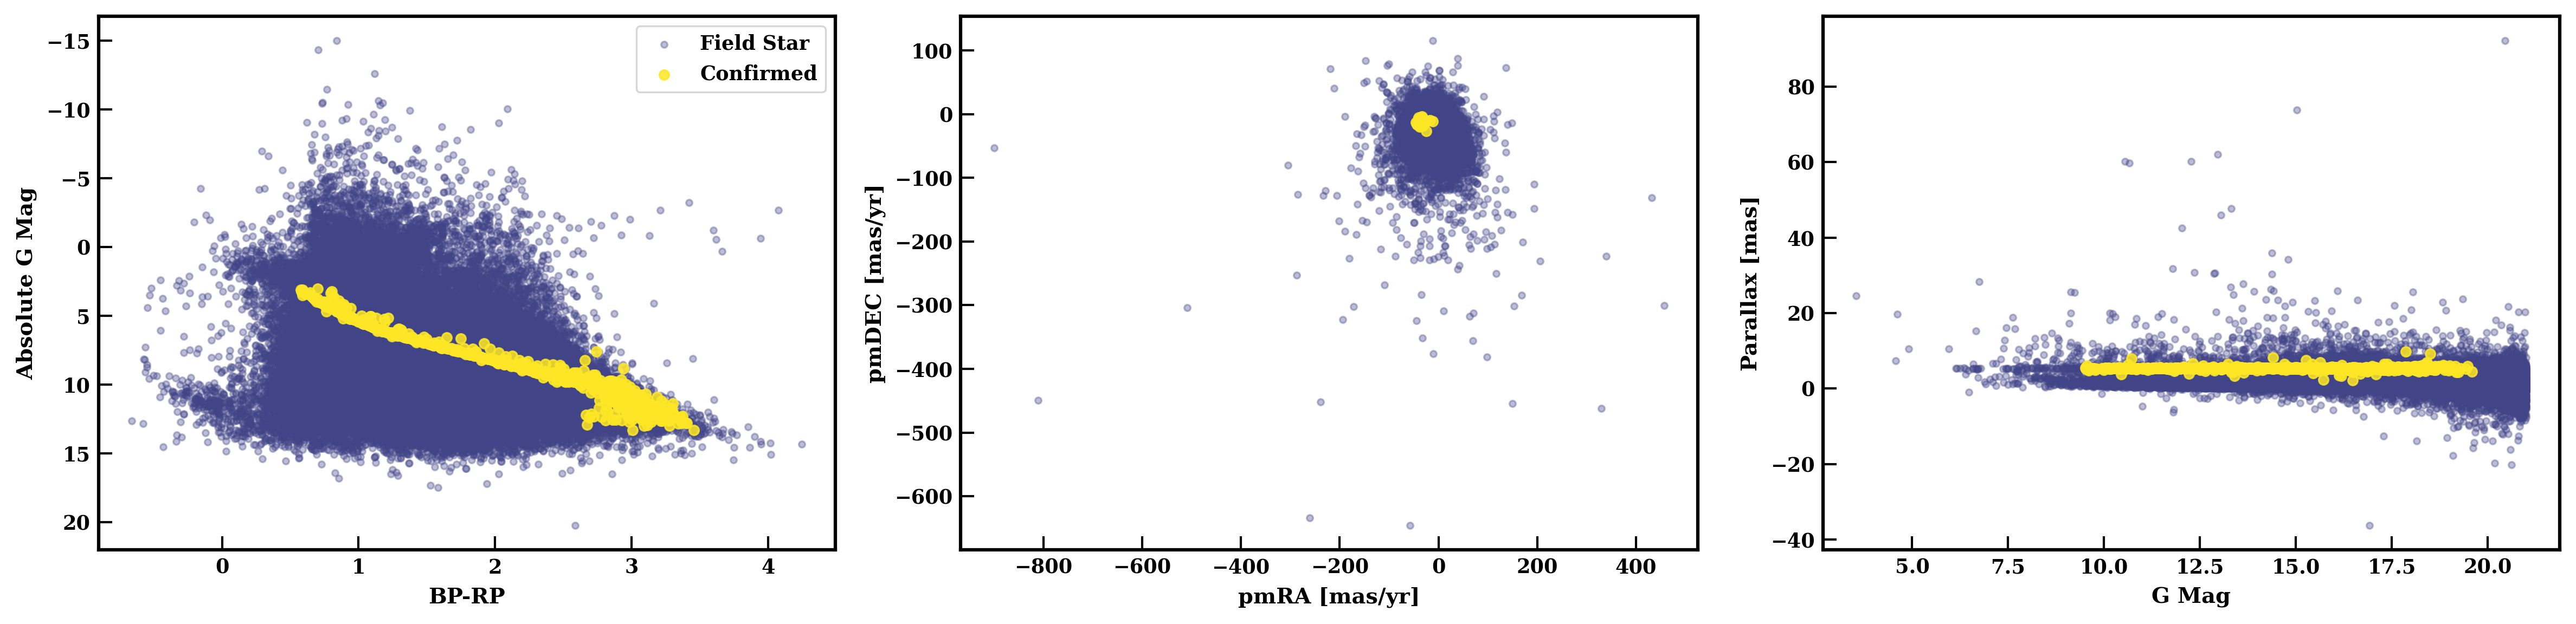

In [248]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=300)

axes[0].scatter(field_df["bp_rp"], field_df["abs_gmag"], s=8, alpha=0.35, label="Field Star", color = colors[1])
axes[0].scatter(confirmed_df["bp_rp"], confirmed_df["abs_gmag"], s=18, alpha=0.85, label="Confirmed", color=colors[5])
axes[0].invert_yaxis()
axes[0].set_xlabel("BP-RP")
axes[0].set_ylabel("Absolute G Mag")
axes[0].legend()

axes[1].scatter(field_df["pmra"], field_df["pmdec"], s=8, alpha=0.35, color = colors[1])
axes[1].scatter(confirmed_df["pmra"], confirmed_df["pmdec"], s=18, alpha=0.85, color = colors[5])
axes[1].set_xlabel("pmRA [mas/yr]")
axes[1].set_ylabel("pmDEC [mas/yr]")

axes[2].scatter(field_df["gmag"], field_df["parallax"], s=8, alpha=0.35, color = colors[1])
axes[2].scatter(confirmed_df["gmag"], confirmed_df["parallax"], s=18, alpha=0.85, color = colors[5])
axes[2].set_xlabel("G Mag")
axes[2].set_ylabel("Parallax [mas]")

plt.tight_layout()
plt.show()

## 3. Build the training sample 

In [169]:
N_FIELD_TRAIN = 2000
rng = np.random.default_rng(RSEED)

if N_FIELD_TRAIN > len(field_df):
    raise ValueError("N_FIELD_TRAIN is larger than the number of available field stars.")

train_field_idx = rng.choice(field_df.index, size=N_FIELD_TRAIN, replace=False)

field_train_df = field_df.loc[train_field_idx].copy()
field_holdout_df = field_df.drop(train_field_idx).copy()

training_df = pd.concat([field_train_df, confirmed_df], ignore_index=True)
training_df = training_df.sample(frac=1, random_state=RSEED).reset_index(drop=True)

X = training_df[FEATURE_COLS]
y = training_df["is_confirmed_member"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.33,
    random_state=RSEED,
)

print(f"Training matrix: {X_train.shape}")
print(f"Test matrix:     {X_test.shape}")
print("\nClass balance")
print("y_train:", y_train.value_counts().to_dict())
print("y_test: ", y_test.value_counts().to_dict())

Training matrix: (1795, 11)
Test matrix:     (885, 11)

Class balance
y_train: {0: 1340, 1: 455}
y_test:  {0: 660, 1: 225}


In [170]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2", None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False],
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RSEED, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=RSEED,
    n_jobs=-1,
)

search.fit(X_train, y_train)
search.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'n_estimators': 200,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'max_depth': None,
 'bootstrap': False}

## 4. Train the Random Forest Classifier

In [171]:
clf = RandomForestClassifier(
    n_estimators=300,
    criterion="gini",
    max_features="sqrt",
    bootstrap=True,
    random_state=RSEED,
    n_jobs=-1,
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

train_pred = clf.predict(X_train)
train_prob = clf.predict_proba(X_train)[:, 1]

### 5. Evaulate the model 

Model performance is evaluated using:

- **Precision**: fraction of predicted members that are true members  
- **Recall**: fraction of true members that are correctly identified  
- **ROC AUC**: overall classification performance across thresholds  

In this context:
- High **recall** → recover more true cluster members (completeness)  
- High **precision** → reduce contamination from field stars  

Both are important for producing a useful candidate list.

In [172]:
def evaluate_classifier(y_true, y_pred, y_prob, split_name="Test"):
    print(f"{split_name} metrics")
    print("-" * 40)
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 score : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    print()

print("Model summary")
print("=" * 40)
evaluate_classifier(y_train, train_pred, train_prob, split_name="Train")
evaluate_classifier(y_test, y_pred, y_prob, split_name="Test")

Model summary
Train metrics
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 score : 1.0000
ROC AUC  : 1.0000

Test metrics
----------------------------------------
Accuracy : 0.9977
Precision: 0.9956
Recall   : 0.9956
F1 score : 0.9956
ROC AUC  : 0.9999



In [173]:
print(classification_report(y_test, y_pred, target_names=["Non-member", "Member"]))

              precision    recall  f1-score   support

  Non-member       1.00      1.00      1.00       660
      Member       1.00      1.00      1.00       225

    accuracy                           1.00       885
   macro avg       1.00      1.00      1.00       885
weighted avg       1.00      1.00      1.00       885



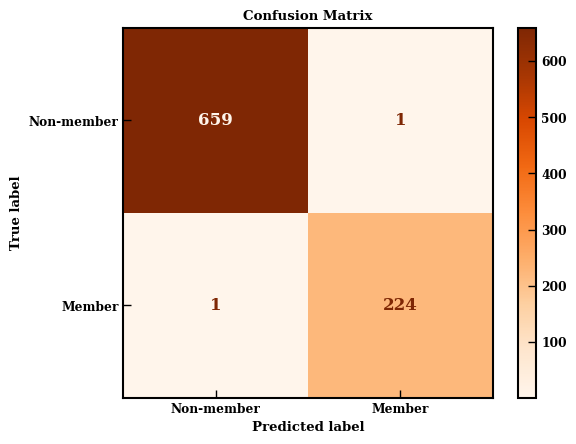

In [174]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-member", "Member"])
disp.plot(cmap="Oranges", values_format="d")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

In the training dataset, there are 660 non-members and 225 members. 

The model correctly identifies nearly all stars, with only two misclassifications:
- **1 false negative**, where a true cluster member was incorrectly classified as a non-member
- **1 false positive**, where a field star was incorrectly classified as a cluster member

This reflects both high completeness (recall) and low contamination (high precision) in the training set.

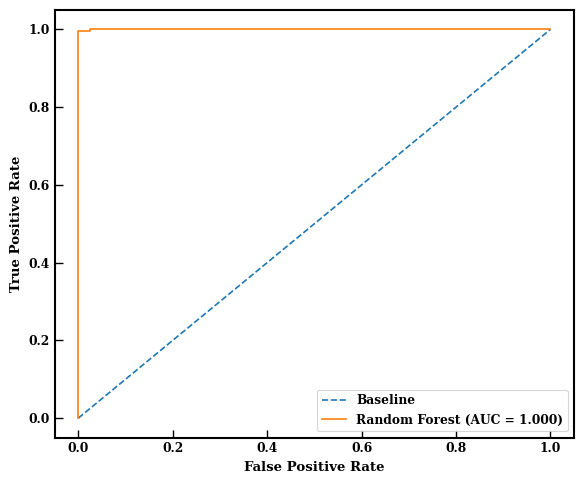

In [175]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Baseline")
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

The Random Forest classifier performs strongly on the test set, indicating that cluster membership can be effectively learned from astrometric and photometric features.

The model successfully distinguishes cluster members from field stars, balancing completeness and contamination.

### 6. Inspect Feature Importance

In [176]:
feature_importance = (
    pd.Series(clf.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=False)
)

feature_importance

pmra        0.348511
parallax    0.335489
pmdec       0.132321
bp_g        0.046793
bp_rp       0.046055
rp_mag      0.040888
gmag        0.020363
bp_mag      0.012512
g_rp        0.008593
dec         0.005413
ra          0.003061
dtype: float64

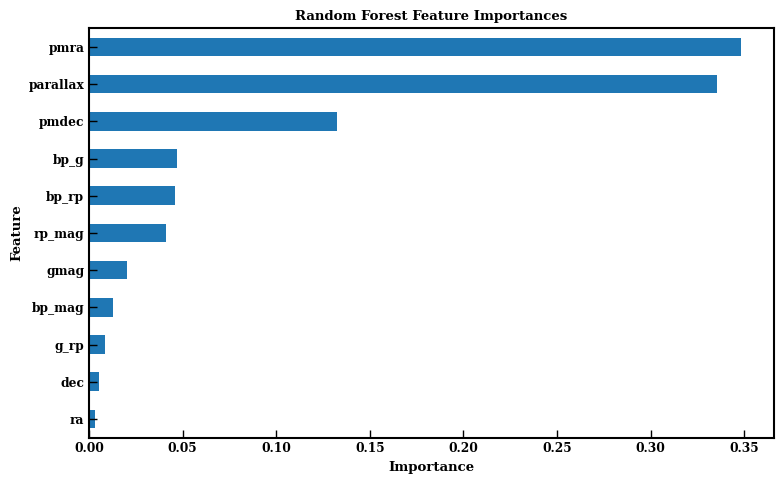

In [177]:
fig, ax = plt.subplots(figsize=(8, 5))
feature_importance.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.set_title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


Feature importance analysis shows that:

- **Parallax and proper motion** are among the most important features, as expected for identifying co-moving stars at similar distances.
- **Photometric colors** also contribute by identifying stars that lie along the cluster sequence.

This aligns with the physical expectations for stellar cluster membership.

### 7. Identify new candidate members  in the unlabeled field sample 

In [178]:
X_field_pred = field_holdout_df[FEATURE_COLS].copy()

field_holdout_df["predicted_member"] = clf.predict(X_field_pred)
field_holdout_df["member_prob"] = clf.predict_proba(X_field_pred)[:, 1]

new_members_df = (
    field_holdout_df[field_holdout_df["predicted_member"] == 1]
    .sort_values("member_prob", ascending=False)
    .reset_index(drop=True)
)

new_nonmembers_df = (
    field_holdout_df[field_holdout_df["predicted_member"] == 0]
    .sort_values("member_prob", ascending=False)
    .reset_index(drop=True)
)

print(f"Predicted new candidate members: {len(new_members_df):,}")
new_members_df.head(10)

Predicted new candidate members: 1,102


,source_id,ra,dec,parallax,pmra,pmdec,gmag,bp_mag,rp_mag,bp_rp,bp_g,g_rp,abs_gmag,is_confirmed_member,predicted_member,member_prob
0,665190039291682560,130.532549,22.184694,5.571284,-38.034433,-15.249010,16.856060,18.407383,15.620671,2.786712,1.551323,1.235389,10.585836,0,1,1.0
1,661265951013145344,129.909694,19.440804,5.345567,-34.757464,-11.636537,12.364870,12.869843,11.684354,1.185489,0.504972,0.680516,6.004839,0,1,1.0
2,664509987053483008,129.510140,20.621180,5.067317,-36.348441,-13.103011,18.260969,20.058788,16.890982,3.167807,1.797819,1.369987,11.784860,0,1,1.0
3,659645030354241536,129.409105,18.482428,5.216754,-35.469187,-11.578977,12.771340,13.338924,12.040760,1.298164,0.567584,0.730580,6.358342,0,1,1.0
4,662812414116269312,128.496691,19.362577,4.876802,-35.329706,-12.814901,14.190128,15.234879,13.173571,2.061308,1.044750,1.016558,7.630804,0,1,1.0
5,661061098251203968,131.645107,19.257179,5.212603,-37.587727,-12.776149,16.697615,18.239103,15.469490,2.769613,1.541489,1.228125,10.282888,0,1,1.0
6,661060479775918592,131.614052,19.209015,5.137122,-38.182341,-12.451878,18.129211,19.856976,16.770569,3.086407,1.727764,1.358643,11.682811,0,1,1.0
7,664513594826132480,129.641973,20.774743,5.132353,-37.222538,-14.277897,17.347422,18.953682,16.083296,2.870386,1.606260,1.264126,10.899004,0,1,1.0
8,662741564335762560,128.665248,19.136834,5.309580,-37.239173,-13.314301,16.644999,18.226166,15.406742,2.819424,1.581167,1.238256,10.270299,0,1,1.0
9,663078530290541952,128.427863,20.244416,5.334664,-34.497502,-14.240277,13.411098,14.118958,12.609795,1.509164,0.707861,0.801303,7.046633,0,1,1.0


In [179]:
# Stars with high predicted probability are flagged as candidate members.
# These candidates represent stars with properties consistent with known cluster members and are strong targets for further astrophysical validation.
high_conf_members = new_members_df[new_members_df["member_prob"] > 0.80].copy()
print(f"High-confidence new members (p > 0.80): {len(high_conf_members):,}")

High-confidence new members (p > 0.80): 545


Using a probability threshold of 0.8, the model identifies 545 high-confidence candidate members. These stars exhibit kinematic and photometric properties consistent with the known Praesepe Cluster population.

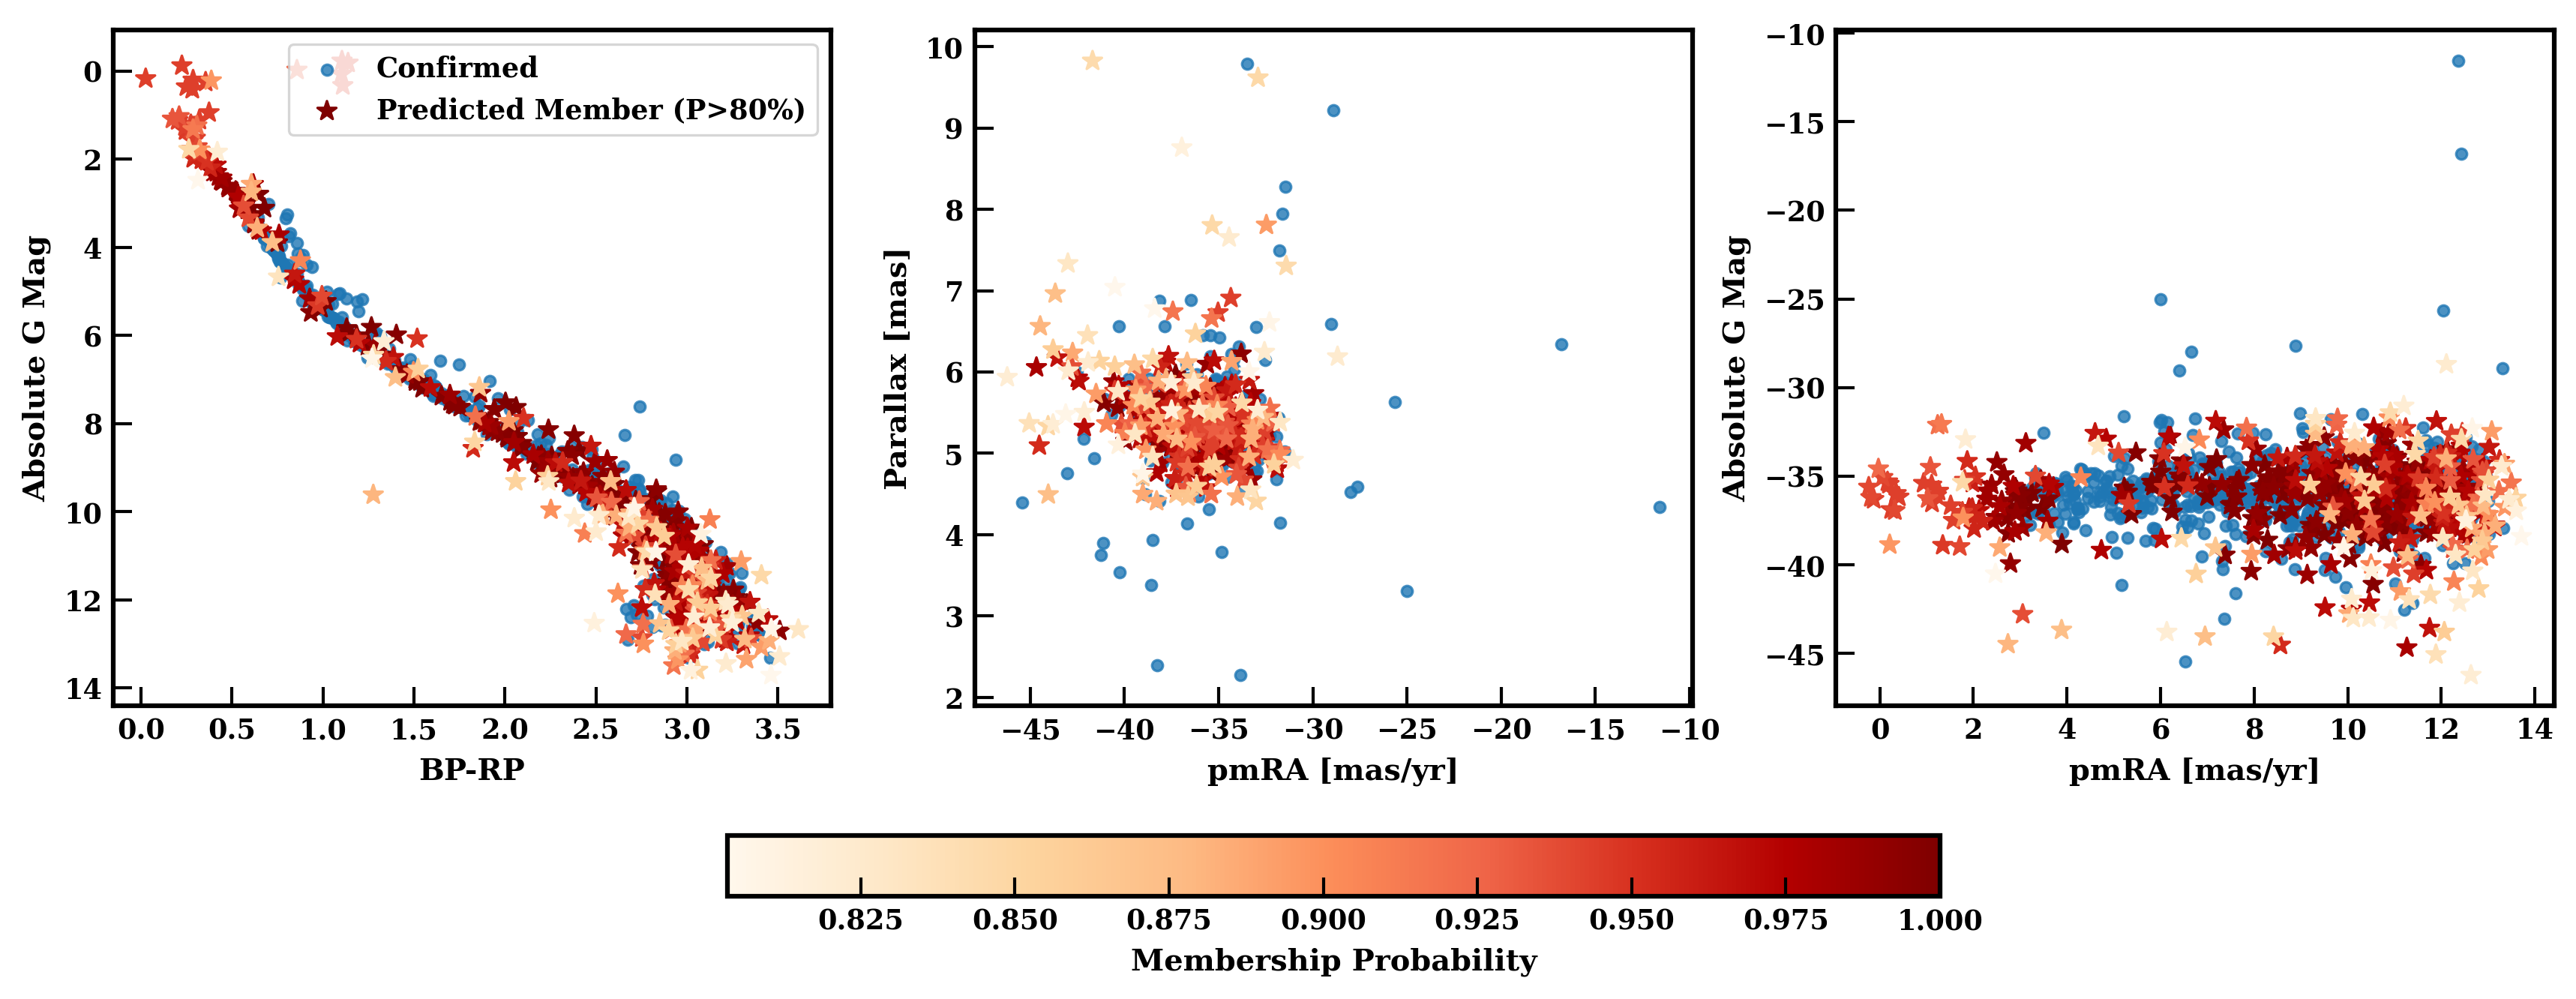

In [253]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), dpi=300)

axes[0].scatter(confirmed_df["bp_rp"], confirmed_df["abs_gmag"], s=12, alpha=0.8, label="Confirmed")
sc =  axes[0].scatter(high_conf_members["bp_rp"], high_conf_members["abs_gmag"], s=40, marker="*", 
                c=high_conf_members["member_prob"], cmap="OrRd", label="Predicted Member (P>80%)")
axes[0].invert_yaxis()
axes[0].set_xlabel("BP-RP")
axes[0].set_ylabel("Absolute G Mag")
axes[0].legend()

axes[1].scatter(confirmed_df["pmra"], confirmed_df["parallax"], s=12, alpha=0.8, label="Confirmed")
axes[1].scatter(high_conf_members["pmra"], high_conf_members["parallax"], s=40, marker="*", c=high_conf_members["member_prob"], cmap="OrRd", label="New")
axes[1].set_xlabel("pmRA [mas/yr]")
axes[1].set_ylabel("Parallax [mas]")

axes[2].scatter(confirmed_df["abs_gmag"], confirmed_df["pmra"], s=12, alpha=0.8, label="Confirmed")
axes[2].scatter(high_conf_members["abs_gmag"], high_conf_members["pmra"], s=40, marker="*", 
                c=high_conf_members["member_prob"], cmap="OrRd")
axes[2].set_xlabel("pmRA [mas/yr]")
axes[2].set_ylabel("Absolute G Mag")

vmin = 0.8
vmax = 1.0
# Create ONE shared colorbar
cbar = fig.colorbar(sc, ax=axes, orientation="horizontal", fraction = 0.07, pad=0.15 )
cbar.set_label("Membership Probability")

#plt.tight_layout()
plt.show()

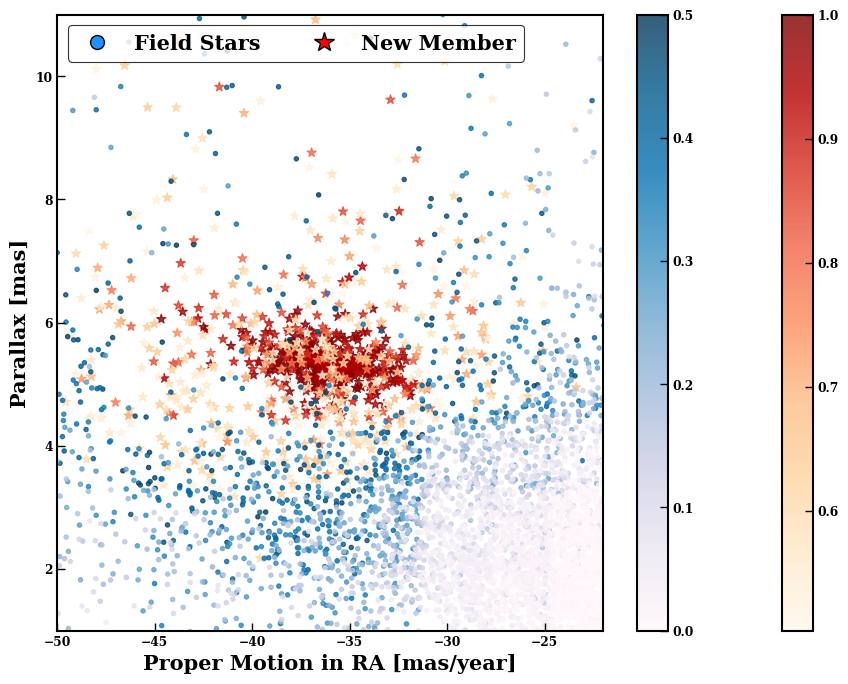

In [230]:
# compare this with the field members 

fig,ax = plt.subplots(1,figsize=(11,8))

a = plt.scatter(new_members_df['pmra'], new_members_df['parallax'],  
            c = new_members_df['member_prob'], marker = '*', alpha = 0.8, cmap = 'OrRd', s = 50)

b = plt.scatter(new_nonmembers_df['pmra'], new_nonmembers_df['parallax'],  
            c = new_nonmembers_df['member_prob'], marker = 'o', alpha = 0.8, cmap = 'PuBu', s = 10)


plt.ylabel("Parallax [mas]", size = 15)
plt.xlabel("Proper Motion in RA [mas/year]", size = 15)

plt.colorbar(a)
plt.colorbar(b)
# create legend objects
blue_circle = mlines.Line2D([], [], color='dodgerblue', marker='o', markeredgecolor = 'black', linestyle='None', markersize=10, label='Field Stars')
red_star = mlines.Line2D([], [], color='red', markeredgecolor = 'black', marker='*', linestyle='None', markersize=15, label='New Member')

plt.xlim([-50, -22])
plt.ylim([1,11])
leg = plt.legend(handles=[blue_circle, red_star], loc = 2, fontsize = 15,  ncol=2)
leg.get_frame().set_edgecolor('black')
plt.show()

Field stars are shown as blue circles, while candidate members identified by the Random Forest classifier are shown as star markers colored by predicted membership probability. The high-confidence candidates cluster tightly around the expected parallax and proper motion values of the cluster, consistent with a co-moving population at a common distance. 

##### Lets check the parallax of the new members and see how it compares with the literature value

In [240]:
med_parallax_mas = np.median(new_members_df['parallax'])
print ("med parallax [mas]: ", med_parallax_mas)
mean_parallax_mas = np.mean(new_members_df['parallax'])
print ("mean parallax [mas]: ", mean_parallax_mas)
# 1 mas = 1/1000 arcsecond
# d [parsecs] = 1/p[arcseconds]
distance_parsec = (1/(mean_parallax_mas * (1/1000)))
print ("distance [parsec]: ", distance_parsec)
quoted_parallax_parsec = 182
real_parallax_mas = (1/(quoted_parallax_parsec*(1/1000)))
print ("literature parallax [mas]: ", real_parallax_mas)

med parallax [mas]:  5.361485664179941
mean parallax [mas]:  5.5964947553925875
distance [parsec]:  178.6832729605321
literature parallax [mas]:  5.4945054945054945


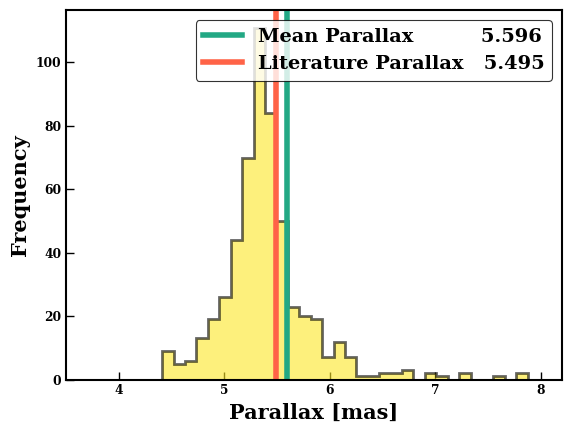

In [241]:
plt.hist(high_conf_members['parallax'], bins = 50, linewidth=2, color = colors[5], histtype='step', edgecolor='black', fill = True, alpha = 0.6)
plt.xlim([3.5,8.2])
plt.ylabel("Frequency", size=15)
plt.xlabel("Parallax [mas]", size = 15)
plt.axvline(x=mean_parallax_mas, color=colors[3], linestyle='-', lw=4, label = 'Mean Parallax          ' + str(np.round(mean_parallax_mas,3)))
plt.axvline(x=real_parallax_mas, color='tomato', linestyle= '-', lw=4, label = 'Literature Parallax   ' + str(np.round(real_parallax_mas,3)))
leg = plt.legend(fontsize=14)
leg.get_frame().set_edgecolor('black')
plt.show()

The parallax values of the high-confidence members are tightly clustered around the literature value for the cluster, providing strong evidence that these candidates lie at the expected distance and are likely true members.

Overall, the model achieves high recall, indicating it successfully recovers most true cluster members, while maintaining reasonable precision, limiting contamination from field stars.

## Limitations

- The model depends on the quality and completeness of the training labels  
- Class imbalance between members and field stars may affect performance  
- Some contamination from field stars is expected  